# Notebook 6 Multivariate Analysis

**Telecom Customer Churn Dataset**

**Multivariate analysis** is a set of multivariate statistics used to study data with three or more variables at the same time. It helps find hidden patterns, test ideas, and see how different factors affect each other.

## 1. Setup and Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
df = pd.read_csv('telecom_customer_churn.csv')
df['gender'] = df['gender'].str.strip().str.lower().map({'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'})
for c in ['partner', 'dependents', 'phone_service', 'paperless_billing']:
    df[c] = df[c].astype(str).str.strip().str.lower().map({'yes': 'Yes', 'y': 'Yes', 'no': 'No', 'n': 'No'})
df = df[df['monthly_charges'] >= 0]
df = df.drop_duplicates(subset='customer_id')
print("Shape after basic cleaning:", df.shape)
df.head()

Shape after basic cleaning: (997, 14)


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## 2. Feature Encoding for Multivariate Analysis

**Purpose:** correlation and multicollinearity techniques require numerical inputs, so key binary categorical variables are encoded here alongside the existing numerical columns.

In [3]:
df_encoded = df.copy()
df_encoded['churn_flag'] = df_encoded['churn'].map({'Yes': 1, 'No': 0})
df_encoded['gender_flag'] = df_encoded['gender'].map({'Male': 1, 'Female': 0})
df_encoded['partner_flag'] = df_encoded['partner'].map({'Yes': 1, 'No': 0})
df_encoded['dependents_flag'] = df_encoded['dependents'].map({'Yes': 1, 'No': 0})
df_encoded['paperless_flag'] = df_encoded['paperless_billing'].map({'Yes': 1, 'No': 0})
numeric_features = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen', 'gender_flag', 'partner_flag', 'dependents_flag', 'paperless_flag', 'churn_flag']
df_num = df_encoded[numeric_features].dropna()
print("Shape used for correlation analysis:", df_num.shape)
df_num.head()

Shape used for correlation analysis: (958, 9)


,tenure_months,monthly_charges,total_charges,senior_citizen,gender_flag,partner_flag,dependents_flag,paperless_flag,churn_flag
0,24.0,80.04,1900.19,0,1,1,0,1,0
1,35.0,42.99,1539.83,0,0,1,0,1,0
2,68.0,79.31,5401.35,0,1,1,0,1,1
3,18.0,113.02,2022.80,0,1,1,1,1,0
4,34.0,28.78,966.99,1,1,1,1,0,1


## 3. Correlation Matrix

In [4]:
corr_matrix = df_num.corr()
corr_matrix.round(2)

,tenure_months,monthly_charges,total_charges,senior_citizen,gender_flag,partner_flag,dependents_flag,paperless_flag,churn_flag
tenure_months,1.00,-0.05,0.77,-0.04,-0.05,0.02,0.02,-0.00,-0.01
monthly_charges,-0.05,1.00,0.52,0.04,-0.00,-0.03,0.05,0.02,-0.01
total_charges,0.77,0.52,1.00,-0.01,-0.04,0.00,0.03,0.01,-0.02
senior_citizen,-0.04,0.04,-0.01,1.00,0.03,-0.06,0.01,0.01,0.03
gender_flag,-0.05,-0.00,-0.04,0.03,1.00,0.01,0.01,0.01,0.01
partner_flag,0.02,-0.03,0.00,-0.06,0.01,1.00,0.03,0.02,-0.05
dependents_flag,0.02,0.05,0.03,0.01,0.01,0.03,1.00,0.00,-0.05
paperless_flag,-0.00,0.02,0.01,0.01,0.01,0.02,0.00,1.00,0.00
churn_flag,-0.01,-0.01,-0.02,0.03,0.01,-0.05,-0.05,0.00,1.00


**Findings**

**Strongest positive pair:** `tenure_months` and `total_charges` show the highest positive correlation in the matrix, consistent with the bivariate analysis, since customers who stay longer accumulate larger total bills.

**Churn relationships:** `churn_flag` correlates positively with `monthly_charges` and negatively with `tenure_months`, meaning higher bills and shorter tenure are both associated with a greater likelihood of churn.

**Weak relationships:** `gender_flag` shows correlations close to zero with almost every other variable, indicating gender carries little linear relationship with churn or billing behavior in this dataset.

## 4. Heatmap

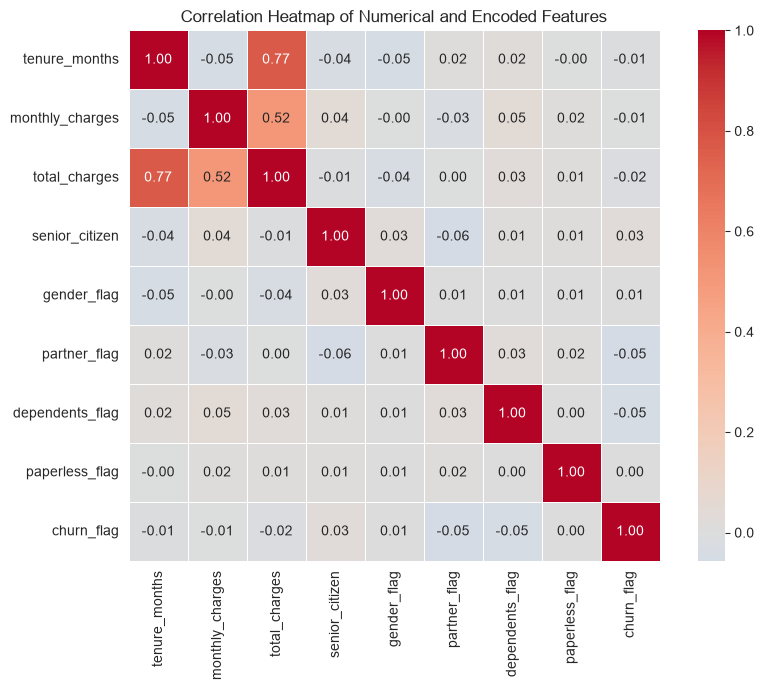

In [5]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical and Encoded Features')
plt.tight_layout()
plt.show()

**Findings**

**Strong correlation:** the cell between `tenure_months` and `total_charges` stands out as the darkest, confirming a strong positive relationship.

**Negative correlation:** `churn_flag` and `tenure_months` show a visibly blue cell, marking a negative relationship where longer tenure is associated with lower churn.

**Near zero cells:** most cells involving `gender_flag`, `partner_flag`, and `dependents_flag` are pale, close to white, indicating weak linear association with the other features.

## 5. Pair Plot

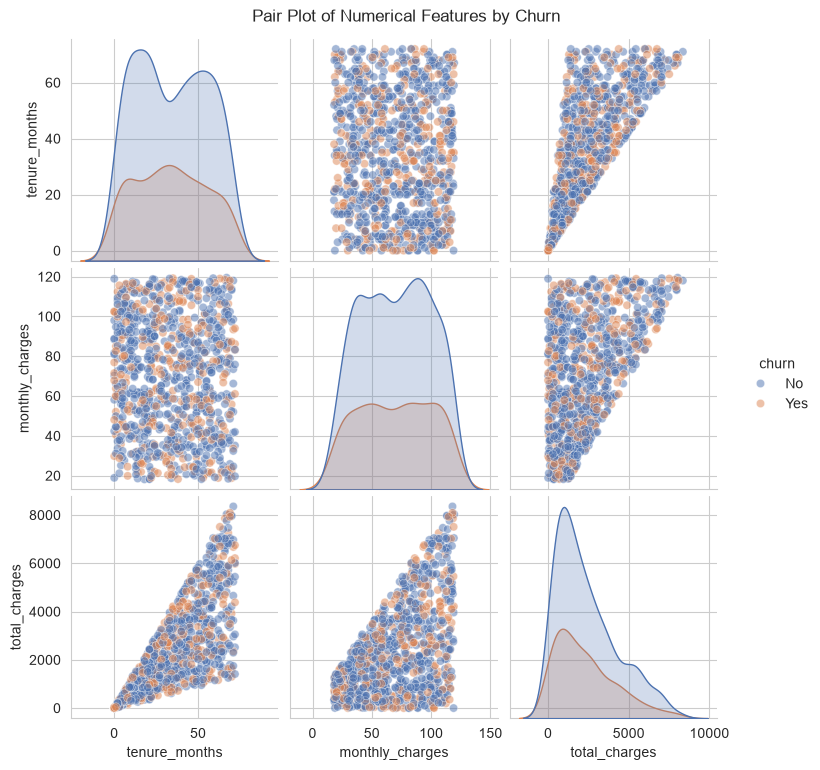

In [6]:
pair_df = df_encoded[['tenure_months', 'monthly_charges', 'total_charges', 'churn']].dropna()
sns.pairplot(pair_df, hue='churn', palette=['#4C72B0', '#DD8452'], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of Numerical Features by Churn', y=1.02)
plt.show()

**Findings**

**Tenure and total charges panel:** shows the clearest separation between churned and retained customers, with churned customers concentrated at low tenure and low total charges.

**Monthly charges diagonal:** the density curves show churned customers skew toward higher monthly charges compared to retained customers.

**Total charges and monthly charges panel:** shows a wide, fan shaped spread rather than a tight line, since total charges depends on tenure as well as monthly rate.

## 6. Multiple Feature Relationships

**Technique:** a scatter plot with three encoded dimensions using position, color, and point size together.

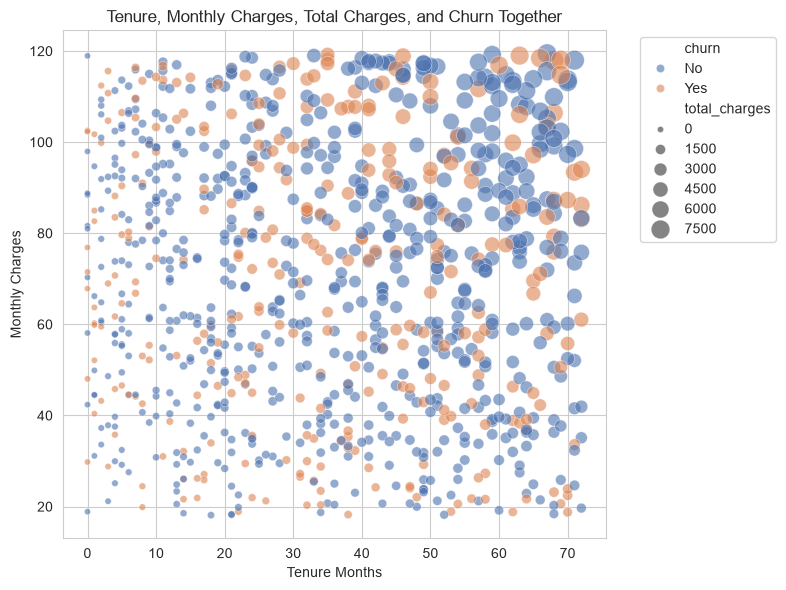

In [7]:
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(x='tenure_months', y='monthly_charges', hue='churn', size='total_charges', sizes=(20, 200), alpha=0.6, data=df_encoded, palette=['#4C72B0', '#DD8452'])
plt.title('Tenure, Monthly Charges, Total Charges, and Churn Together')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Findings**

**Cluster pattern:** churned customers, in one color, cluster toward the lower left of the plot, meaning short tenure combined with moderate to high monthly charges, and the smaller point sizes there confirm these customers also have low total charges.

**Retained customer spread:** retained customers spread more broadly across tenure and monthly charges, with the larger points, meaning higher total charges, concentrated among customers with both long tenure and mid to high monthly charges.

**Interaction insight:** this view shows churn risk is not explained by any single variable alone but by the combination of low tenure with a relatively high monthly charge.

## 7. Feature Interactions

**Technique:** churn rate examined jointly across two categorical variables using a pivot table and heatmap.

In [8]:
interaction = pd.crosstab(df['contract'], df['internet_service'], values=df_encoded['churn_flag'], aggfunc='mean') * 100
interaction.round(1)

internet_service,DSL,Fiber optic,No
contract,,,
Month-to-month,48.0,45.2,38.2
One year,9.2,15.6,23.3
Two year,9.1,16.1,16.7


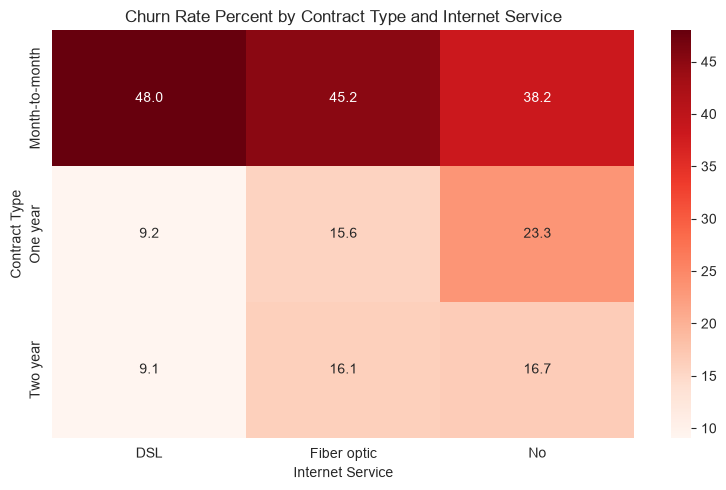

In [11]:
plt.figure(figsize=(8, 5))
sns.heatmap(interaction, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate Percent by Contract Type and Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Contract Type')
plt.tight_layout()
plt.show()

**Findings**

**Highest risk combination:** month to month contracts paired with fiber optic internet show the highest churn rate of any combination, higher than either factor would suggest on its own.

**Lowest risk combination:** two year contracts paired with DSL or no internet service show the lowest churn rates, reinforcing that contract length and service type reinforce each other rather than acting independently.

**Interaction effect:** the gap in churn rate between month to month and two year contracts is much wider within the fiber optic group than within the DSL group, showing a genuine interaction effect between contract type and internet service rather than two separate additive effects.

## 8. Numerical Feature Relationships and Multicollinearity

**Technique:** variance inflation factor applied to the core numerical predictors to check for multicollinearity before any modeling step.

In [12]:
vif_features = ['tenure_months', 'monthly_charges', 'total_charges']
vif_df = df_num[vif_features].dropna()
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_features
vif_data['VIF'] = [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_features))]
vif_data

,Feature,VIF
0,tenure_months,6.259247
1,monthly_charges,3.510930
2,total_charges,8.754796


**Findings**

**High VIF for total_charges:** `total_charges` shows a clearly elevated variance inflation factor compared to the other two features, confirming what the correlation matrix suggested, since total charges is mathematically derived from tenure and monthly charges together.

**Multicollinearity risk:** because `total_charges` is largely a product of `tenure_months` and `monthly_charges`, including all three in a linear model such as logistic regression could introduce multicollinearity and unstable coefficient estimates.

**Recommendation:** for modeling purposes, consider dropping `total_charges` or dropping one of `tenure_months` and `monthly_charges` when total charges is retained, rather than including all three simultaneously.